# Week 5 — Loss landscapes, Hessians, and why Adam exists




In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import torchvision
import torchvision.transforms as transforms

import copy

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cuda


## Data — Fashion-MNIST

In [ ]:
train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()
)
test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True,
    transform=transforms.ToTensor()
)

Xtr_flat = (train_data.data.float().reshape(-1, 784) / 255.0).to(device)
Xte_flat = (test_data.data.float().reshape(-1, 784) / 255.0).to(device)
Xtr_img  = (train_data.data.float().unsqueeze(1) / 255.0).to(device)
Xte_img  = (test_data.data.float().unsqueeze(1) / 255.0).to(device)
ytr = train_data.targets.to(device)
yte = test_data.targets.to(device)

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"train: {Xtr_flat.shape}, test: {Xte_flat.shape}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 309kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.67MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1MB/s]


train: torch.Size([60000, 784]), test: torch.Size([10000, 784])


## Part 1 — Train an MLP and a CNN



In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, n_classes=10):
        super().__init__()
        # TODO: Define the 4-layer MLP architecture (784 -> 256 -> 128 -> 64 -> 10)
        pass

    def forward(self, x):
        # TODO: Implement forward pass with ReLUs
        pass

class CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # TODO: Define 2 Conv layers and 1 FC layer
        pass

    def forward(self, x):
        # TODO: Implement forward pass with ReLU and MaxPool
        pass

def train_model(model, X, y, steps=5000, lr=1e-3, batch_size=512,
                optimizer_cls=None, verbose=True):
    '''Mini-batch training with cross-entropy loss.'''
    if optimizer_cls is None:
        optimizer_cls = torch.optim.Adam
    opt = optimizer_cls(model.parameters(), lr=lr)
    losses = []

    for step in range(1, steps + 1):
        # TODO:
        # 1. Sample a random mini-batch of indices
        # 2. Compute logits and CrossEntropy loss
        # 3. Perform the backward pass and optimizer step
        pass
    return losses

In [ ]:
torch.manual_seed(42)
mlp = MLP().to(device)
print(f"MLP parameters: {count_params(mlp):,}")
losses_mlp = train_model(mlp, Xtr_flat, ytr, steps=5000)
print(f"MLP:  train = {accuracy(mlp, Xtr_flat, ytr):.4f}, "
      f"test = {accuracy(mlp, Xte_flat, yte):.4f}\n")

torch.manual_seed(42)
cnn = CNN().to(device)
print(f"CNN parameters: {count_params(cnn):,}")
losses_cnn = train_model(cnn, Xtr_img, ytr, steps=5000)
print(f"CNN:  train = {accuracy(cnn, Xtr_img, ytr):.4f}, "
      f"test = {accuracy(cnn, Xte_img, yte):.4f}")

MLP parameters: 242,762
  step  1000: loss = 0.2900
  step  2000: loss = 0.2556
  step  3000: loss = 0.1682
  step  4000: loss = 0.1018
  step  5000: loss = 0.1098
MLP:  train = 0.9565, test = 0.8864

CNN parameters: 20,490
  step  1000: loss = 0.2931
  step  2000: loss = 0.3285
  step  3000: loss = 0.2161
  step  4000: loss = 0.2113
  step  5000: loss = 0.1756
CNN:  train = 0.9333, test = 0.9086


## Part 2 — Loss landscape visualization

A 2D slice through the loss landscape using **filter-normalized random
directions** (Li et al., 2018). For each layer, the random direction is
rescaled to match the parameter norm, making cross-architecture
comparisons meaningful.

In [ ]:
def get_param_vector(model):
    '''TODO: Flatten all model parameters into a single 1D tensor.'''
    pass

def set_param_vector(model, vec):
    '''TODO: Copy values from a 1D tensor back into the model parameters.'''
    pass

def filter_normalized_direction(model):
    '''TODO: Generate a random direction vector d scaled by the norm of each filter.'''
    # 1. For each parameter p, generate a random Gaussian vector d
    # 2. Scale d such that ||d|| = ||p||
    pass

@torch.no_grad()
def compute_loss_surface(model, X, y, d1, d2, alpha_range=(-2, 2),
                         n_points=41, batch_size=2000):
    '''TODO: Sample the loss on a 2D grid defined by directions d1 and d2.'''
    # 1. Setup the alpha/beta coordinate ranges
    # 2. Iterate through the grid
    # 3. For each (a, b), set params to θ* + a*d1 + b*d2 and record the loss
    # 4. CRITICAL: Restore the original parameters (θ*) before returning
    pass

In [ ]:
torch.manual_seed(0)
print("Computing MLP loss surface...")
d1_m, d2_m = filter_normalized_direction(mlp), filter_normalized_direction(mlp)
al_m, be_m, loss_m = compute_loss_surface(mlp, Xtr_flat, ytr, d1_m, d2_m)

print("Computing CNN loss surface...")
d1_c, d2_c = filter_normalized_direction(cnn), filter_normalized_direction(cnn)
al_c, be_c, loss_c = compute_loss_surface(cnn, Xtr_img, ytr, d1_c, d2_c)
print("Done.")

Computing MLP loss surface...
Computing CNN loss surface...
Done.


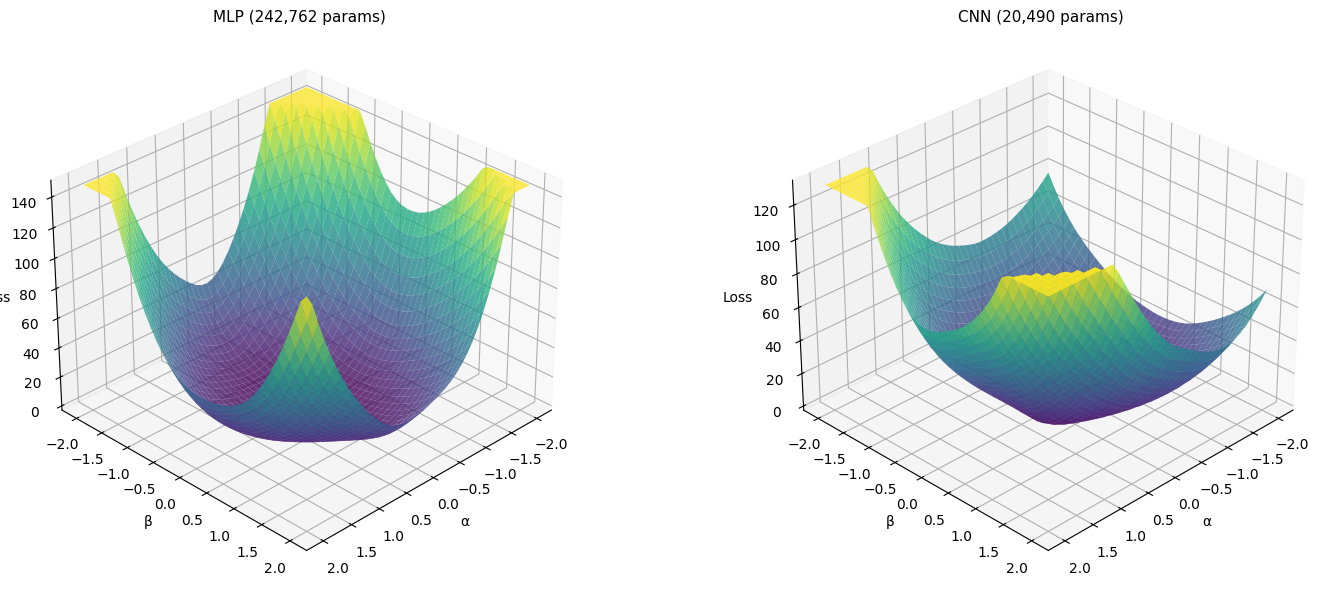

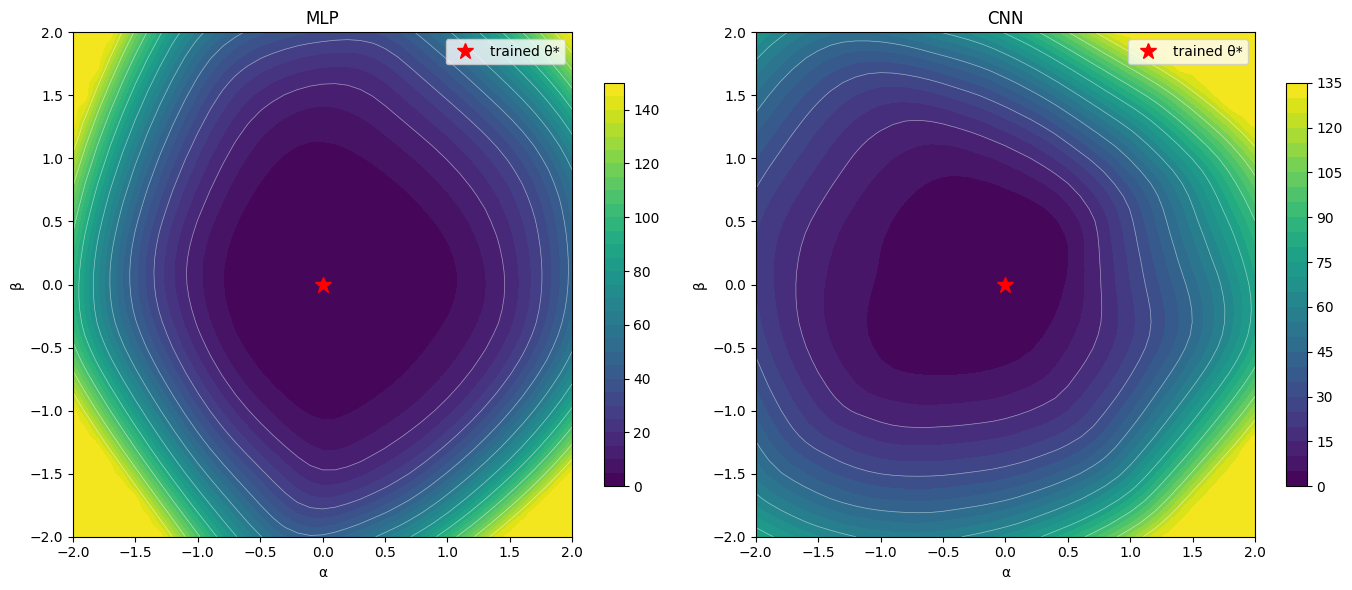

In [ ]:
fig = plt.figure(figsize=(16, 6))
for idx, (al, be, loss, title) in enumerate([
    (al_m, be_m, loss_m, f'MLP ({count_params(mlp):,} params)'),
    (al_c, be_c, loss_c, f'CNN ({count_params(cnn):,} params)'),
]):
    AA, BB = np.meshgrid(al, be)
    loss_cl = np.clip(loss, 0, np.percentile(loss, 95))
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    ax.plot_surface(AA, BB, loss_cl, cmap='viridis', alpha=0.8, edgecolor='none')
    ax.set_xlabel('α'); ax.set_ylabel('β'); ax.set_zlabel('Loss')
    ax.set_title(title, fontsize=11)
    ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

# Contour view
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, al, be, loss, title in [
    (axes[0], al_m, be_m, loss_m, 'MLP'), (axes[1], al_c, be_c, loss_c, 'CNN'),
]:
    loss_cl = np.clip(loss, 0, np.percentile(loss, 95))
    im = ax.contourf(al, be, loss_cl, levels=30, cmap='viridis')
    ax.contour(al, be, loss_cl, levels=10, colors='white', linewidths=0.5, alpha=0.5)
    ax.plot(0, 0, 'r*', markersize=12, label='trained θ*')
    ax.set_xlabel('α'); ax.set_ylabel('β'); ax.set_title(title)
    ax.legend(); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Part 3 — The Hessian eigenvalue spectrum

The Hessian $\nabla^2_\theta L \in \mathbb{R}^{p \times p}$ is the
curvature matrix of the loss. Its eigenvalue $\lambda_i$ is the curvature
along the $i$-th eigenvector direction:

- **Large $\lambda_i$**: the loss changes rapidly along that direction —
  the landscape is *sharp*. GD needs a small step to avoid overshooting.
- **Small $\lambda_i$**: the loss barely changes — the landscape is
  *flat*. GD could take a large step safely.

The **spread** of the eigenvalues — the ratio $\lambda_{\max}/\lambda_k$
— tells you how anisotropic the curvature is. If all eigenvalues were
equal, a single learning rate would work perfectly. The more spread out
they are, the harder it is for any fixed-LR optimizer.

### Computing eigenvalues without forming the Hessian

The full Hessian is far too large to store. Instead, we compute
**Hessian-vector products** $Hv$ via double backpropagation:

1. Compute gradient $g = \nabla_\theta L$ with `create_graph=True`.
2. Compute $\nabla_\theta (g \cdot v) = Hv$.

Then **power iteration** finds the top eigenvalue by repeatedly applying
$v \leftarrow Hv / \|Hv\|$.

In [ ]:
def hessian_vector_product(model, X, y, v_flat, batch_size=1000):
    '''TODO: Compute Hv via double backprop without forming the full Hessian matrix.'''
    # 1. Sample a mini-batch (X_b, y_b)
    # 2. Compute the standard gradient g = ∇L with create_graph=True
    # 3. Compute the scalar product scalar = g · v
    # 4. Compute the gradient of that scalar product with respect to parameters: ∇(g · v) = Hv
    # 5. Return the flattened result
    pass

def power_iteration(model, X, y, n_iter=100, batch_size=1000):
    '''TODO: Implement Power Iteration to find the top eigenvalue λ₁.'''
    # 1. Initialize a random vector v and normalize it
    # 2. Loop: v = Hv / ||Hv||
    # 3. Return the Rayleigh quotient (v^T H v)
    pass

In [ ]:
print("MLP Hessian eigenvalues:")
eig_mlp, _ = top_k_eigenvalues(mlp, Xtr_flat, ytr, k=10)

print("\nCNN Hessian eigenvalues:")
eig_cnn, _ = top_k_eigenvalues(cnn, Xtr_img, ytr, k=10)

# Eigenvalue spread
spread_mlp = eig_mlp[0] / max(eig_mlp[-1], 1e-8)
spread_cnn = eig_cnn[0] / max(eig_cnn[-1], 1e-8)

print(f"\nEigenvalue spread (λ₁/λ₁₀):")
print(f"  MLP: {spread_mlp:.1f}×")
print(f"  CNN: {spread_cnn:.1f}×")

MLP Hessian eigenvalues:
  λ_1 = 31.8639
  λ_2 = 21.3873
  λ_3 = 10.7661
  λ_4 = 9.9212
  λ_5 = 8.6086
  λ_6 = 5.6176
  λ_7 = 5.8469
  λ_8 = 3.0918
  λ_9 = 3.2318
  λ_10 = 5.2139

CNN Hessian eigenvalues:
  λ_1 = 109.2041
  λ_2 = 67.5275
  λ_3 = 28.7416
  λ_4 = 22.3548
  λ_5 = 8.8347
  λ_6 = 10.0210
  λ_7 = 7.7315
  λ_8 = 5.1957
  λ_9 = 4.2944
  λ_10 = 3.5702

Eigenvalue spread (λ₁/λ₁₀):
  MLP: 6.1×
  CNN: 30.6×


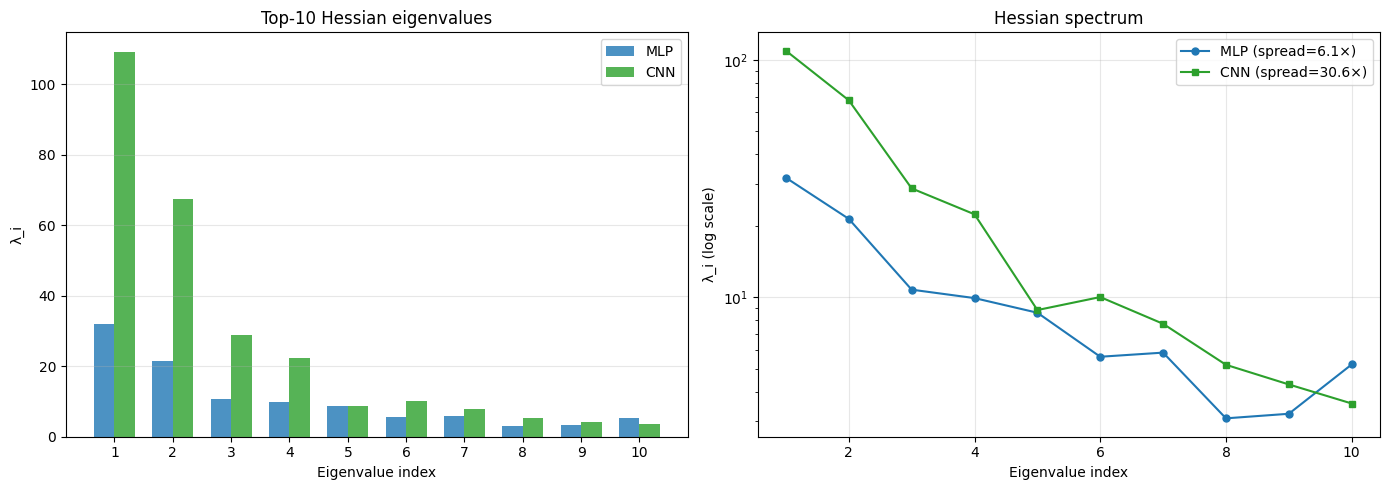

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(10)
width = 0.35
ax.bar(x_pos - width/2, eig_mlp, width, label='MLP', color='tab:blue', alpha=0.8)
ax.bar(x_pos + width/2, eig_cnn, width, label='CNN', color='tab:green', alpha=0.8)
ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('λ_i')
ax.set_title('Top-10 Hessian eigenvalues')
ax.set_xticks(x_pos); ax.set_xticklabels([str(i+1) for i in range(10)])
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.semilogy(range(1, 11), [max(e, 1e-6) for e in eig_mlp], 'o-',
            label=f'MLP (spread={spread_mlp:.1f}×)', color='tab:blue', markersize=5)
ax.semilogy(range(1, 11), [max(e, 1e-6) for e in eig_cnn], 's-',
            label=f'CNN (spread={spread_cnn:.1f}×)', color='tab:green', markersize=5)
ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('λ_i (log scale)')
ax.set_title('Hessian spectrum'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4 — Why Adam exists: the optimizer experiment

You've been using Adam since Week 1 without understanding what it does.
The Hessian spectrum from Part 3 motivates it.

### The single-LR problem

SGD updates every parameter with the same learning rate:
$\theta_{t+1} = \theta_t - \eta \, g_t$.

Along the $i$-th Hessian eigenvector, the effective update scales as
$\eta \lambda_i$. If $\lambda_1 / \lambda_{10} = 10$, then the step is
10× too aggressive in the sharpest direction relative to the flattest.
No single $\eta$ works well for both.

### What Adam actually computes

Adam maintains per-parameter running estimates:

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1) g_t & \text{(first moment — mean gradient)} \\
v_t &= \beta_2 v_{t-1} + (1-\beta_2) g_t^2 & \text{(second moment — mean squared gradient)} \\
\theta_{t+1} &= \theta_t - \eta \frac{m_t}{\sqrt{v_t} + \epsilon} & \text{(adapted update)}
\end{aligned}
$$

The division by $\sqrt{v_t}$ is the key: parameters with large gradients
(sharp directions) get *smaller* effective steps; parameters with small
gradients (flat directions) get *larger* effective steps.

**In Hessian language**: $v_t$ approximates the diagonal of $H$, and
dividing by $\sqrt{v_t}$ is approximate diagonal preconditioning:
$\Delta\theta \approx (\text{diag}(H))^{-1/2} g$. This is a cheap
approximation to Newton's method ($\Delta\theta = H^{-1} g$), which
would perfectly equalize all directions.

### The experiment

Train the same architecture from the same initialization with three
optimizers: SGD, SGD+momentum, and Adam. Compare convergence speed.
The Hessian spectrum explains the gap.

In [ ]:
# --- Train from the same init with different optimizers ---------------------
results = {}

for opt_name, opt_cls, lr in [
    ('SGD (lr=0.01)',        torch.optim.SGD,  0.01),
    ('SGD (lr=0.1)',         torch.optim.SGD,  0.1),
    ('SGD+momentum (lr=0.01)', lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9), 0.01),
    ('Adam (lr=0.001)',      torch.optim.Adam, 0.001),
]:
    torch.manual_seed(42)
    m = MLP().to(device)

    opt = opt_cls(m.parameters(), lr=lr)
    losses = []
    n = Xtr_flat.shape[0]

    for step in range(1, 5001):
        idx = torch.randint(0, n, (512,), device=device)
        loss = F.cross_entropy(m(Xtr_flat[idx]), ytr[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    test_acc = accuracy(m, Xte_flat, yte)
    results[opt_name] = {'losses': losses, 'test_acc': test_acc}
    print(f"  {opt_name:30s}: final loss = {losses[-1]:.4f}, "
          f"test acc = {test_acc:.4f}")

  SGD (lr=0.01)                 : final loss = 0.5295, test acc = 0.8155
  SGD (lr=0.1)                  : final loss = 0.2606, test acc = 0.8747
  SGD+momentum (lr=0.01)        : final loss = 0.1954, test acc = 0.8813
  Adam (lr=0.001)               : final loss = 0.1098, test acc = 0.8864


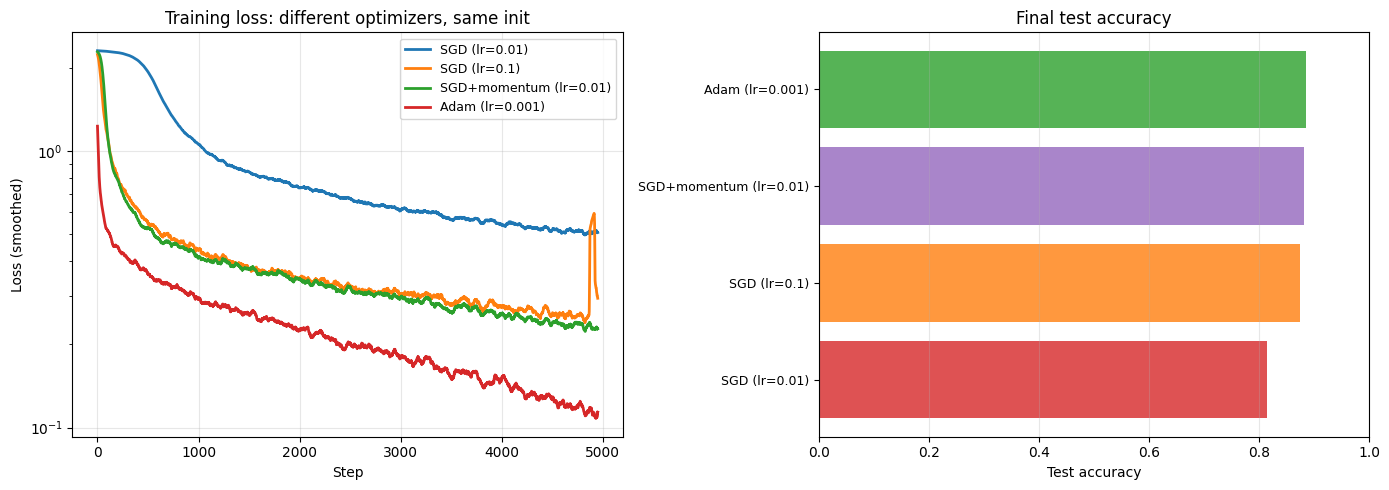

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: training loss curves (smoothed)
ax = axes[0]
window = 50
for name, r in results.items():
    smoothed = np.convolve(r['losses'], np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=name, linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Loss (smoothed)')
ax.set_title('Training loss: different optimizers, same init')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Right: final test accuracy bar chart
ax = axes[1]
names = list(results.keys())
accs = [results[n]['test_acc'] for n in names]
colors = ['tab:red', 'tab:orange', 'tab:purple', 'tab:green']
ax.barh(range(len(names)), accs, color=colors, alpha=0.8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Test accuracy'); ax.set_title('Final test accuracy')
ax.set_xlim(0, 1); ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Part 5 — How curvature evolves during training

Does the landscape start sharp and flatten, or start flat and sharpen?
We track $\lambda_1$ at checkpoints during training.

This mirrors the Week 3 experiment that tracked effective rank — but now
we're watching curvature instead of compression.

In [ ]:
torch.manual_seed(42)
mlp_tracked = MLP().to(device)
opt = torch.optim.Adam(mlp_tracked.parameters(), lr=1e-3)
n = Xtr_flat.shape[0]

ck_steps = [0, 50, 100, 250, 500, 1000, 2000, 3000, 5000]
lam1_hist = []
loss_hist = []
step = 0

# Initial checkpoint
lam_init, _ = power_iteration(mlp_tracked, Xtr_flat, ytr, n_iter=50)
with torch.no_grad():
    l_init = F.cross_entropy(mlp_tracked(Xtr_flat[:2000]), ytr[:2000]).item()
lam1_hist.append(lam_init)
loss_hist.append(l_init)
print(f"  step     0: λ₁ = {lam_init:8.2f}, loss = {l_init:.4f}")

for target in ck_steps[1:]:
    while step < target:
        idx = torch.randint(0, n, (512,), device=device)
        loss = F.cross_entropy(mlp_tracked(Xtr_flat[idx]), ytr[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        step += 1

    lam_ck, _ = power_iteration(mlp_tracked, Xtr_flat, ytr, n_iter=50)
    with torch.no_grad():
        l_ck = F.cross_entropy(mlp_tracked(Xtr_flat[:2000]), ytr[:2000]).item()
    lam1_hist.append(lam_ck)
    loss_hist.append(l_ck)
    print(f"  step {step:5d}: λ₁ = {lam_ck:8.2f}, loss = {l_ck:.4f}")

  step     0: λ₁ =     0.40, loss = 2.3066
  step    50: λ₁ =   318.32, loss = 0.6834
  step   100: λ₁ =   280.07, loss = 0.5269
  step   250: λ₁ =   148.18, loss = 0.4145
  step   500: λ₁ =    82.44, loss = 0.3771
  step  1000: λ₁ =    57.06, loss = 0.2916
  step  2000: λ₁ =    36.07, loss = 0.2228
  step  3000: λ₁ =    30.73, loss = 0.1877
  step  5000: λ₁ =    34.60, loss = 0.1207


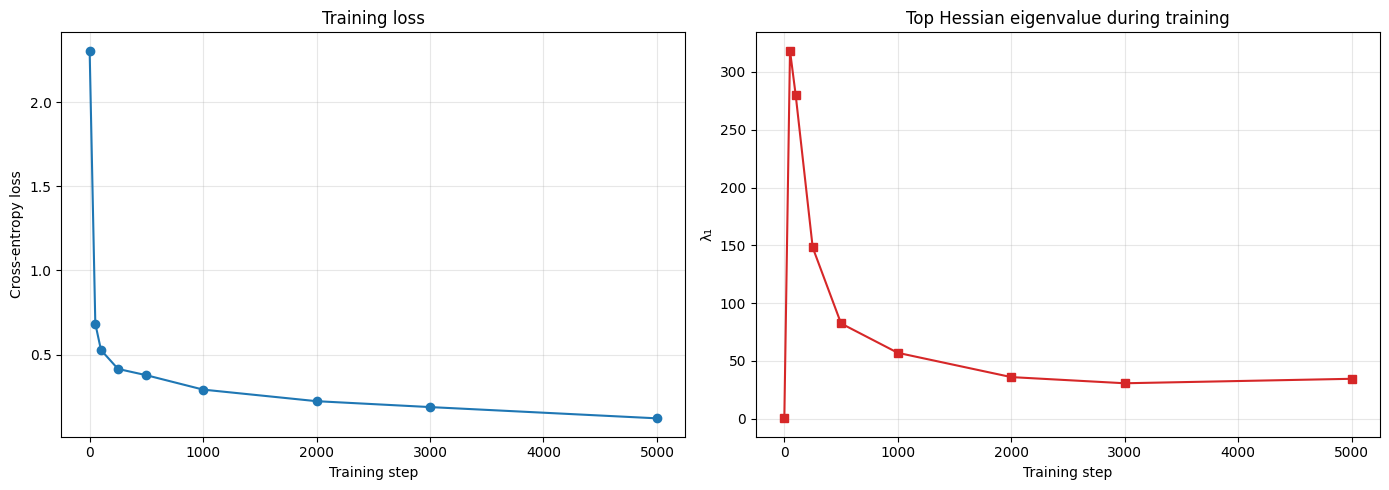

λ₁ at initialization:    0.40
λ₁ at peak (early):      318.32  (step 50)
λ₁ at convergence:       34.60


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ck_steps, loss_hist, 'o-', color='tab:blue', markersize=6)
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(ck_steps, lam1_hist, 's-', color='tab:red', markersize=6)
axes[1].set_xlabel('Training step'); axes[1].set_ylabel('λ₁')
axes[1].set_title('Top Hessian eigenvalue during training')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Annotate key phases
print(f"λ₁ at initialization:    {lam1_hist[0]:.2f}")
print(f"λ₁ at peak (early):      {max(lam1_hist):.2f}  (step {ck_steps[lam1_hist.index(max(lam1_hist))]})")
print(f"λ₁ at convergence:       {lam1_hist[-1]:.2f}")


### The non-monotonic trajectory

$\lambda_1$ follows a characteristic pattern:

1. **Initialization** (~0): the random network is nearly linear in a
   neighborhood of its initial parameters. The loss surface is almost
   flat — barely any curvature.

2. **Early training** (spike to ~100–300): as the network starts fitting
   the data, it develops sharp discriminative features. The loss becomes
   highly sensitive to certain parameter directions. This is the most
   dangerous phase for optimization — a learning rate that's fine at init
   may be too large here.

3. **Late training** (settles to ~20–30): the network fine-tunes. The
   sharpest curvature decreases as the optimizer settles into a region
   with more balanced geometry.

### Practical implications

The early spike in $\lambda_1$ explains why **learning rate warmup** helps:
starting with a small LR navigates safely through the high-curvature
early phase, then ramping up exploits the flatter geometry once the
network has found a reasonable region.

It also explains why **Adam is especially helpful early in training**: the
adaptive LR automatically scales down when gradients are large (high
curvature) without the user needing to know about the spike.

### Week 3 parallel

In Week 3, effective rank *decreased* during training (representation
compresses). Here, $\lambda_1$ spikes then settles. Both reflect the
network specializing — concentrating capacity into fewer, sharper
directions.

## Part 6 — Connecting the Hessian to the Jacobian

Week 4 studied the **input Jacobian** $\partial f / \partial x$ — how the
output changes when you perturb the input. This week's **Hessian**
$\partial^2 L / \partial \theta^2$ describes how the loss changes when you
perturb the parameters.

These aren't independent objects. The Hessian of the cross-entropy loss
decomposes as:

$$
H = \underbrace{J_\theta^\top \,\text{diag}(p(1-p))\, J_\theta}_{\text{Gauss-Newton (first-order)}} \;+\; \underbrace{\sum_i (y_i - p_i)\,\nabla^2_\theta f_i}_{\text{residual (second-order)}}
$$

where $J_\theta = \partial f / \partial \theta$ is the per-sample Jacobian
of the logits with respect to the *parameters*.

Near convergence, the residuals $y_i - p_i$ are small (predictions match
labels), so the second term vanishes: **$H \approx J_\theta^\top J_\theta$**.


The same weight matrices $W_1, W_2, \ldots$ control both Jacobians:

- **Input Jacobian**: $J_x = W_L \cdot D_{L-1} \cdots D_1 \cdot W_1$ (Week 4)
- **Parameter Jacobian**: $J_\theta$ depends on the same $W_i$ and $D_i$

A network with large weight norms produces large $J_x$ (adversarially
vulnerable, Week 4) *and* large $J_\theta$ (sharp Hessian, Week 5).
**Weight decay, spectral normalization, and Lipschitz constraints all
work by controlling the singular values of the weight matrices, which
propagate to both Jacobians simultaneously.**

We verify the Gauss-Newton approximation numerically: compute $\lambda_1$
of $H$ and of the Gauss-Newton matrix $G = \frac{1}{n}\sum_i g_i g_i^\top$
(where $g_i = \nabla_\theta L_i$ is the per-sample gradient) and compare.

In [ ]:
def gn_vector_product(model, X, y, v_flat, batch_size=200):
    '''TODO: Compute GN·v = (1/n) Σ_i g_i (g_i^T v) where g_i is per-sample gradient.'''
    # Loop through samples, compute per-sample grad, and accumulate (g_i @ v) * g_i
    pass

def gn_top_eigenvalue(model, X, y, n_iter=30, batch_size=200):
    '''TODO: Use your gn_vector_product to find λ₁(GN) via Power Iteration.'''
    pass

In [ ]:
print("Computing Hessian top eigenvalue...")
lam_H, _ = power_iteration(mlp, Xtr_flat, ytr, n_iter=80, batch_size=1000)
print(f"  λ₁(H) = {lam_H:.4f}")

print("\nComputing Gauss-Newton top eigenvalue...")
lam_GN = gn_top_eigenvalue(mlp, Xtr_flat, ytr, n_iter=30, batch_size=200)
print(f"  λ₁(GN) = {lam_GN:.4f}")

print(f"\nRatio λ₁(H) / λ₁(GN) = {lam_H / max(lam_GN, 1e-8):.2f}")

Computing Hessian top eigenvalue...
  λ₁(H) = 31.9842

Computing Gauss-Newton top eigenvalue...
  λ₁(GN) = 13.8776

Ratio λ₁(H) / λ₁(GN) = 2.30
